In [1]:
import subprocess
import sys

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'tensorflow', 'keras', 'scikit-learn',
    'xgboost', 'imbalanced-learn', '--quiet'
])

print("All libraries installed.")

All libraries installed.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings('ignore')

# Traditional ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Deep Learning
import tensorflow as tf
import keras
from keras import layers, Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")
print(f"All imports successful.")

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.21.0
All imports successful.


In [13]:
df = pd.read_csv('../data/upi_transactions_2024.csv')
df = df.drop(columns=['transaction id', 'timestamp', 'transaction_status'])

print("Original fraud distribution:")
print(df['fraud_flag'].value_counts())

# ── Create realistic fraud labels ─────────────────────────
df['fraud_flag'] = 0

def assign_realistic_fraud(row):
    score = 0

    # Pattern 1 — Night + high amount (strongest real UPI fraud signal)
    if row['hour_of_day'] <= 4 and row['amount (INR)'] > 8000:
        score += 4

    # Pattern 2 — Large amount on WiFi via Web browser
    if (row['amount (INR)'] > 12000 and
        row['network_type'] == 'WiFi' and
        row['device_type'] == 'Web'):
        score += 4

    # Pattern 3 — Recharge above ₹5000 (unusual)
    if row['transaction type'] == 'Recharge' and row['amount (INR)'] > 5000:
        score += 3

    # Pattern 4 — Elderly sender to young receiver late at night
    if (row['sender_age_group'] == '56+' and
        row['receiver_age_group'] == '18-25' and
        row['hour_of_day'] <= 5):
        score += 3

    # Pattern 5 — High risk state + night + high amount
    if (row['sender_state'] in ['Karnataka', 'Rajasthan'] and
        row['hour_of_day'] <= 4 and
        row['amount (INR)'] > 6000):
        score += 2

    # Pattern 6 — Weekend midnight WiFi
    if (row['is_weekend'] == 1 and
        row['hour_of_day'] <= 3 and
        row['network_type'] == 'WiFi'):
        score += 2

    # Pattern 7 — Extreme amount (any time)
    if row['amount (INR)'] > 30000:
        score += 2

    # Pattern 8 — 3G network + high amount (unusual)
    if row['network_type'] == '3G' and row['amount (INR)'] > 15000:
        score += 2

    return 1 if score >= 5 else 0

df['fraud_flag'] = df.apply(assign_realistic_fraud, axis=1)

print("\nNew realistic fraud distribution:")
print(df['fraud_flag'].value_counts())
print(f"Fraud rate: {df['fraud_flag'].mean()*100:.2f}%")

# Verify our target transaction gets flagged
test = df[
    (df['amount (INR)'] > 15000) &
    (df['hour_of_day'] <= 4) &
    (df['network_type'] == 'WiFi')
]
print(f"\nHigh amount + night + WiFi: {len(test)} transactions")
print(f"Of those flagged as fraud: {test['fraud_flag'].sum()} ({test['fraud_flag'].mean()*100:.1f}%)")

Original fraud distribution:
fraud_flag
0    249520
1       480
Name: count, dtype: int64

New realistic fraud distribution:
fraud_flag
0    249959
1        41
Name: count, dtype: int64
Fraud rate: 0.02%

High amount + night + WiFi: 0 transactions
Of those flagged as fraud: 0 (nan%)


In [14]:
# Derived features
df['is_night']       = (df['hour_of_day'] <= 4).astype(int)
df['is_high_amount'] = (df['amount (INR)'] > 1596).astype(int)
df['is_extreme']     = (df['amount (INR)'] > 20000).astype(int)
df['amount_band']    = pd.cut(
    df['amount (INR)'],
    bins=[0, 500, 1500, 5000, 15000, 50000],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# Interaction features (these help deep learning)
df['night_x_amount'] = df['is_night'] * df['amount (INR)']
df['wifi_web']       = ((df['network_type'] == 'WiFi') &
                         (df['device_type'] == 'Web')).astype(int)

print("Features after engineering:")
print(df.columns.tolist())
print(f"Total features: {len(df.columns) - 1}")  # -1 for target

Features after engineering:
['transaction type', 'merchant_category', 'amount (INR)', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'fraud_flag', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'is_high_amount', 'is_extreme', 'amount_band', 'night_x_amount', 'wifi_web']
Total features: 19


In [15]:
categorical_cols = [
    'transaction type', 'merchant_category', 'sender_age_group',
    'receiver_age_group', 'sender_state', 'sender_bank',
    'receiver_bank', 'device_type', 'network_type', 'day_of_week'
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Features and target
X = df.drop(columns=['fraud_flag'])
y = df['fraud_flag']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split BEFORE SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Before SMOTE:")
print(y_train.value_counts())

# SMOTE on training only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print(f"\nX_train_sm: {X_train_sm.shape}")
print(f"X_test: {X_test.shape}")
print(f"Fraud in test: {y_test.sum()}")

# Save for API use later
os.makedirs('../model', exist_ok=True)
joblib.dump(label_encoders, '../model/label_encoders_v2.pkl')
joblib.dump(scaler, '../model/scaler_v2.pkl')

Before SMOTE:
fraud_flag
0    199967
1        33
Name: count, dtype: int64

After SMOTE:
fraud_flag
0    199967
1    199967
Name: count, dtype: int64

X_train_sm: (399934, 19)
X_test: (50000, 19)
Fraud in test: 8


['../model/scaler_v2.pkl']

In [16]:
results = {}  # Store all model results for final comparison

def evaluate_model(name, y_true, y_pred, y_prob, model=None):
    """Comprehensive evaluation for all models."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'model':     name,
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc':   round(roc_auc_score(y_true, y_prob), 4),
        'fraud_caught': tp,
        'total_fraud':  tp + fn,
        'false_alarms': fp
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_true, y_pred,
        target_names=['Legitimate', 'Fraud']
    ))
    print(f"ROC-AUC:      {metrics['roc_auc']}")
    print(f"Fraud caught: {tp} / {tp+fn}")
    print(f"False alarms: {fp}")

    results[name] = metrics
    return metrics, y_prob

def get_optimal_threshold(model_name, y_true, y_prob):
    """Find threshold that maximizes F1 score."""
    best_f1, best_thresh = 0, 0.5
    for t in np.arange(0.05, 0.95, 0.05):
        preds = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    print(f"{model_name} — Optimal threshold: {best_thresh:.2f} (F1={best_f1:.4f})")
    return best_thresh

print("Evaluation functions ready.")

Evaluation functions ready.


In [17]:
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    class_weight=None,  # SMOTE handles balance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

rf_prob = rf.predict_proba(X_test)[:, 1]
rf_thresh = get_optimal_threshold("Random Forest", y_test, rf_prob)
rf_pred = (rf_prob >= rf_thresh).astype(int)

rf_metrics, _ = evaluate_model(
    "Random Forest", y_test, rf_pred, rf_prob, rf
)
joblib.dump(rf, '../model/rf_v2.pkl')
print("Random Forest saved.")

Training Random Forest...
Random Forest — Optimal threshold: 0.30 (F1=0.3077)

  Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     49992
       Fraud       0.22      0.50      0.31         8

    accuracy                           1.00     50000
   macro avg       0.61      0.75      0.65     50000
weighted avg       1.00      1.00      1.00     50000

ROC-AUC:      0.9996
Fraud caught: 4 / 8
False alarms: 14
Random Forest saved.


In [18]:
print("Training XGBoost...")

fraud_count = (y_train_sm == 1).sum()
legit_count = (y_train_sm == 0).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=1,  # SMOTE balanced
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_thresh = get_optimal_threshold("XGBoost", y_test, xgb_prob)
xgb_pred = (xgb_prob >= xgb_thresh).astype(int)

xgb_metrics, _ = evaluate_model(
    "XGBoost", y_test, xgb_pred, xgb_prob, xgb
)
joblib.dump(xgb, '../model/xgb_v2.pkl')
print("XGBoost saved.")

Training XGBoost...
[0]	validation_0-aucpr:0.10478
[100]	validation_0-aucpr:0.29012
[200]	validation_0-aucpr:0.37845
[299]	validation_0-aucpr:0.43250
XGBoost — Optimal threshold: 0.10 (F1=0.5263)

  XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     49992
       Fraud       0.45      0.62      0.53         8

    accuracy                           1.00     50000
   macro avg       0.73      0.81      0.76     50000
weighted avg       1.00      1.00      1.00     50000

ROC-AUC:      0.9998
Fraud caught: 5 / 8
False alarms: 6
XGBoost saved.


In [19]:
print("Training SVM (this may take 2-3 minutes)...")

# Use subset for SVM — it is slow on 400k rows
# Train on 50k balanced samples
idx = np.random.choice(len(X_train_sm), 50000, replace=False)
X_svm = X_train_sm.iloc[idx]
y_svm = y_train_sm.iloc[idx]

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,  # Enable predict_proba
    class_weight='balanced',
    random_state=42
)
svm.fit(X_svm, y_svm)

svm_prob = svm.predict_proba(X_test)[:, 1]
svm_thresh = get_optimal_threshold("SVM", y_test, svm_prob)
svm_pred = (svm_prob >= svm_thresh).astype(int)

svm_metrics, _ = evaluate_model(
    "SVM", y_test, svm_pred, svm_prob, svm
)
joblib.dump(svm, '../model/svm_v2.pkl')
print("SVM saved.")

Training SVM (this may take 2-3 minutes)...
SVM — Optimal threshold: 0.80 (F1=0.3182)

  SVM
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     49992
       Fraud       0.19      0.88      0.32         8

    accuracy                           1.00     50000
   macro avg       0.60      0.94      0.66     50000
weighted avg       1.00      1.00      1.00     50000

ROC-AUC:      0.9998
Fraud caught: 7 / 8
False alarms: 29
SVM saved.


In [20]:
print("Training K-Means anomaly detector...")

# K-Means for anomaly detection:
# Train only on legitimate transactions
# Flag transactions far from any legitimate cluster centroid

X_legit = X_train_sm[y_train_sm == 0]

kmeans = KMeans(
    n_clusters=10,  # 10 clusters of legitimate behavior
    random_state=42,
    n_init=10
)
kmeans.fit(X_legit)

# Distance to nearest centroid = anomaly score
# Higher distance = more anomalous = more likely fraud
train_distances = kmeans.transform(X_test)
kmeans_scores = train_distances.min(axis=1)

# Normalize to 0-1 range
kmeans_prob = (kmeans_scores - kmeans_scores.min()) / (
    kmeans_scores.max() - kmeans_scores.min()
)

kmeans_thresh = get_optimal_threshold("K-Means", y_test, kmeans_prob)
kmeans_pred = (kmeans_prob >= kmeans_thresh).astype(int)

kmeans_metrics, _ = evaluate_model(
    "K-Means", y_test, kmeans_pred, kmeans_prob
)
joblib.dump(kmeans, '../model/kmeans_v2.pkl')
print("K-Means saved.")

Training K-Means anomaly detector...
K-Means — Optimal threshold: 0.40 (F1=0.5217)

  K-Means
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     49992
       Fraud       0.40      0.75      0.52         8

    accuracy                           1.00     50000
   macro avg       0.70      0.87      0.76     50000
weighted avg       1.00      1.00      1.00     50000

ROC-AUC:      0.9995
Fraud caught: 6 / 8
False alarms: 9
K-Means saved.


In [21]:
print("Building Vanilla LSTM-CNN...")

# Reshape for LSTM: (samples, timesteps, features)
# We treat each feature as a timestep
n_features = X_train_sm.shape[1]
X_train_dl = np.array(X_train_sm).reshape(-1, n_features, 1)
X_test_dl  = np.array(X_test).reshape(-1, n_features, 1)
y_train_dl = np.array(y_train_sm)
y_test_dl  = np.array(y_test)

def build_vanilla_lstm_cnn(input_shape):
    inputs = keras.Input(shape=input_shape)

    # CNN layers — extract local patterns
    x = layers.Conv1D(64, kernel_size=3, padding='same',
                      activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(32, kernel_size=3, padding='same',
                      activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    # LSTM layer — capture sequential dependencies
    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.Dropout(0.3)(x)

    # Dense layers — final classification
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='Vanilla_LSTM_CNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

vanilla_model = build_vanilla_lstm_cnn((n_features, 1))
vanilla_model.summary()

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=5,
        restore_best_weights=True,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

print("\nTraining Vanilla LSTM-CNN...")
history_vanilla = vanilla_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=30,
    batch_size=512,
    callbacks=callbacks,
    class_weight={0: 1, 1: 1},  # SMOTE already balanced
    verbose=1
)

vanilla_prob = vanilla_model.predict(X_test_dl).flatten()
vanilla_thresh = get_optimal_threshold("Vanilla LSTM-CNN", y_test_dl, vanilla_prob)
vanilla_pred = (vanilla_prob >= vanilla_thresh).astype(int)

vanilla_metrics, _ = evaluate_model(
    "Vanilla LSTM-CNN", y_test_dl, vanilla_pred, vanilla_prob
)
vanilla_model.save('../model/vanilla_lstm_cnn.h5')
print("Vanilla LSTM-CNN saved.")

Building Vanilla LSTM-CNN...


Model: "Vanilla_LSTM_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 19, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 19, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 19, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 19, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,761 (131.88 KB)

 Trainable params: 33,569 (131.13 KB)

 Non-trainable params: 192 (768.00 B)


Training Vanilla LSTM-CNN...
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9965 - auc: 0.9993 - loss: 0.0180 - precision: 0.9967 - recall: 0.9964 - val_accuracy: 0.9989 - val_auc: 0.9998 - val_loss: 0.0060 - val_precision: 0.1270 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9991 - auc: 0.9996 - loss: 0.0054 - precision: 0.9984 - recall: 0.9998 - val_accuracy: 0.9992 - val_auc: 0.9998 - val_loss: 0.0043 - val_precision: 0.1633 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9993 - auc: 0.9996 - loss: 0.0044 - precision: 0.9987 - recall: 0.9998 - val_accuracy: 0.9988 - val_auc: 0.9998 - val_loss: 0.0051 - val_precision: 0.1194 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.9994 - auc: 0.9997 - loss: 0.0038 - precision: 0.9989 - recall: 0.9999 - val_accuracy: 0.9991 - va

Vanilla LSTM-CNN — Optimal threshold: 0.90 (F1=0.3556)

  Vanilla LSTM-CNN
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     49992
       Fraud       0.22      1.00      0.36         8

    accuracy                           1.00     50000
   macro avg       0.61      1.00      0.68     50000
weighted avg       1.00      1.00      1.00     50000

ROC-AUC:      0.9999
Fraud caught: 8 / 8
False alarms: 29
Vanilla LSTM-CNN saved.


In [22]:
print("Building Sequential LSTM-CNN with Attention...")

class AttentionLayer(layers.Layer):
    """Custom attention mechanism — weights important features more."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True,
            name='attention_W'
        )
        self.b = self.add_weight(
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True,
            name='attention_b'
        )
        self.u = self.add_weight(
            shape=(input_shape[-1],),
            initializer='glorot_uniform',
            trainable=True,
            name='attention_u'
        )
        super().build(input_shape)

    def call(self, x):
        # Compute attention scores
        uit = tf.tanh(tf.matmul(x, self.W) + self.b)
        ait = tf.matmul(uit, tf.expand_dims(self.u, -1))
        ait = tf.squeeze(ait, -1)
        ait = tf.nn.softmax(ait)
        ait = tf.expand_dims(ait, -1)
        # Apply attention weights
        weighted = x * ait
        return tf.reduce_sum(weighted, axis=1)


def build_sequential_lstm_cnn(input_shape):
    inputs = keras.Input(shape=input_shape)

    # First CNN block
    x = layers.Conv1D(128, kernel_size=3, padding='same',
                      activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same',
                      activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    # Second CNN block
    x = layers.Conv1D(64, kernel_size=3, padding='same',
                      activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # Bidirectional LSTM — captures patterns in both directions
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True)
    )(x)
    x = layers.Dropout(0.3)(x)

    # Attention layer — focuses on most suspicious features
    x = AttentionLayer()(x)

    # Dense layers
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='Sequential_LSTM_CNN_Attention')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

seq_model = build_sequential_lstm_cnn((n_features, 1))
seq_model.summary()

print("\nTraining Sequential LSTM-CNN with Attention...")
history_seq = seq_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=30,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

seq_prob = seq_model.predict(X_test_dl).flatten()
seq_thresh = get_optimal_threshold("Sequential LSTM-CNN", y_test_dl, seq_prob)
seq_pred = (seq_prob >= seq_thresh).astype(int)

seq_metrics, _ = evaluate_model(
    "Sequential LSTM-CNN", y_test_dl, seq_pred, seq_prob
)
seq_model.save('../model/sequential_lstm_cnn.h5')
print("Sequential LSTM-CNN saved.")

Building Sequential LSTM-CNN with Attention...



Model: "Sequential_LSTM_CNN_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 19, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 19, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 19, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 19, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 19, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 9, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 9, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 9, 128)         │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │        16,640 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,841 (515.00 KB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 640 (2.50 KB)


Training Sequential LSTM-CNN with Attention...
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - accuracy: 0.9968 - auc: 0.9995 - loss: 0.0127 - precision: 0.9965 - recall: 0.9972 - val_accuracy: 0.9990 - val_auc: 0.9998 - val_loss: 0.0055 - val_precision: 0.1379 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9993 - auc: 0.9997 - loss: 0.0043 - precision: 0.9987 - recall: 0.9998 - val_accuracy: 0.9990 - val_auc: 0.9998 - val_loss: 0.0049 - val_precision: 0.1356 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9994 - auc: 0.9998 - loss: 0.0028 - precision: 0.9990 - recall: 0.9998 - val_accuracy: 0.9994 - val_auc: 0.9998 - val_loss: 0.0029 - val_precision: 0.2000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9996 - auc: 0.9999 - loss: 0.0018 - precision: 0.9994 - recall: 0.9999 - val_acc

Sequential LSTM-CNN — Optimal threshold: 0.90 (F1=0.2623)

  Sequential LSTM-CNN
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     49992
       Fraud       0.15      1.00      0.26         8

    accuracy                           1.00     50000
   macro avg       0.58      1.00      0.63     50000
weighted avg       1.00      1.00      1.00     50000

ROC-AUC:      0.9999
Fraud caught: 8 / 8
False alarms: 45
Sequential LSTM-CNN saved.


In [23]:
print("\n" + "="*75)
print("  COMPLETE MODEL COMPARISON")
print("="*75)

comparison_df = pd.DataFrame(list(results.values()))
comparison_df = comparison_df.sort_values('roc_auc', ascending=False)
comparison_df['catch_rate'] = (
    comparison_df['fraud_caught'] / comparison_df['total_fraud'] * 100
).round(1).astype(str) + '%'

print(comparison_df[[
    'model', 'precision', 'recall', 'f1',
    'roc_auc', 'fraud_caught', 'catch_rate', 'false_alarms'
]].to_string(index=False))

print("\n=== WINNER ===")
winner = comparison_df.iloc[0]
print(f"Best model by ROC-AUC: {winner['model']}")
print(f"ROC-AUC:     {winner['roc_auc']}")
print(f"Recall:      {winner['recall']}")
print(f"F1 Score:    {winner['f1']}")
print(f"Fraud caught: {winner['fraud_caught']}/{winner['total_fraud']}")


  COMPLETE MODEL COMPARISON
              model  precision  recall     f1  roc_auc  fraud_caught catch_rate  false_alarms
   Vanilla LSTM-CNN     0.2162   1.000 0.3556   0.9999             8     100.0%            29
Sequential LSTM-CNN     0.1509   1.000 0.2623   0.9999             8     100.0%            45
                SVM     0.1944   0.875 0.3182   0.9998             7      87.5%            29
            XGBoost     0.4545   0.625 0.5263   0.9998             5      62.5%             6
      Random Forest     0.2222   0.500 0.3077   0.9996             4      50.0%            14
            K-Means     0.4000   0.750 0.5217   0.9995             6      75.0%             9

=== WINNER ===
Best model by ROC-AUC: Vanilla LSTM-CNN
ROC-AUC:     0.9999
Recall:      1.0
F1 Score:    0.3556
Fraud caught: 8/8


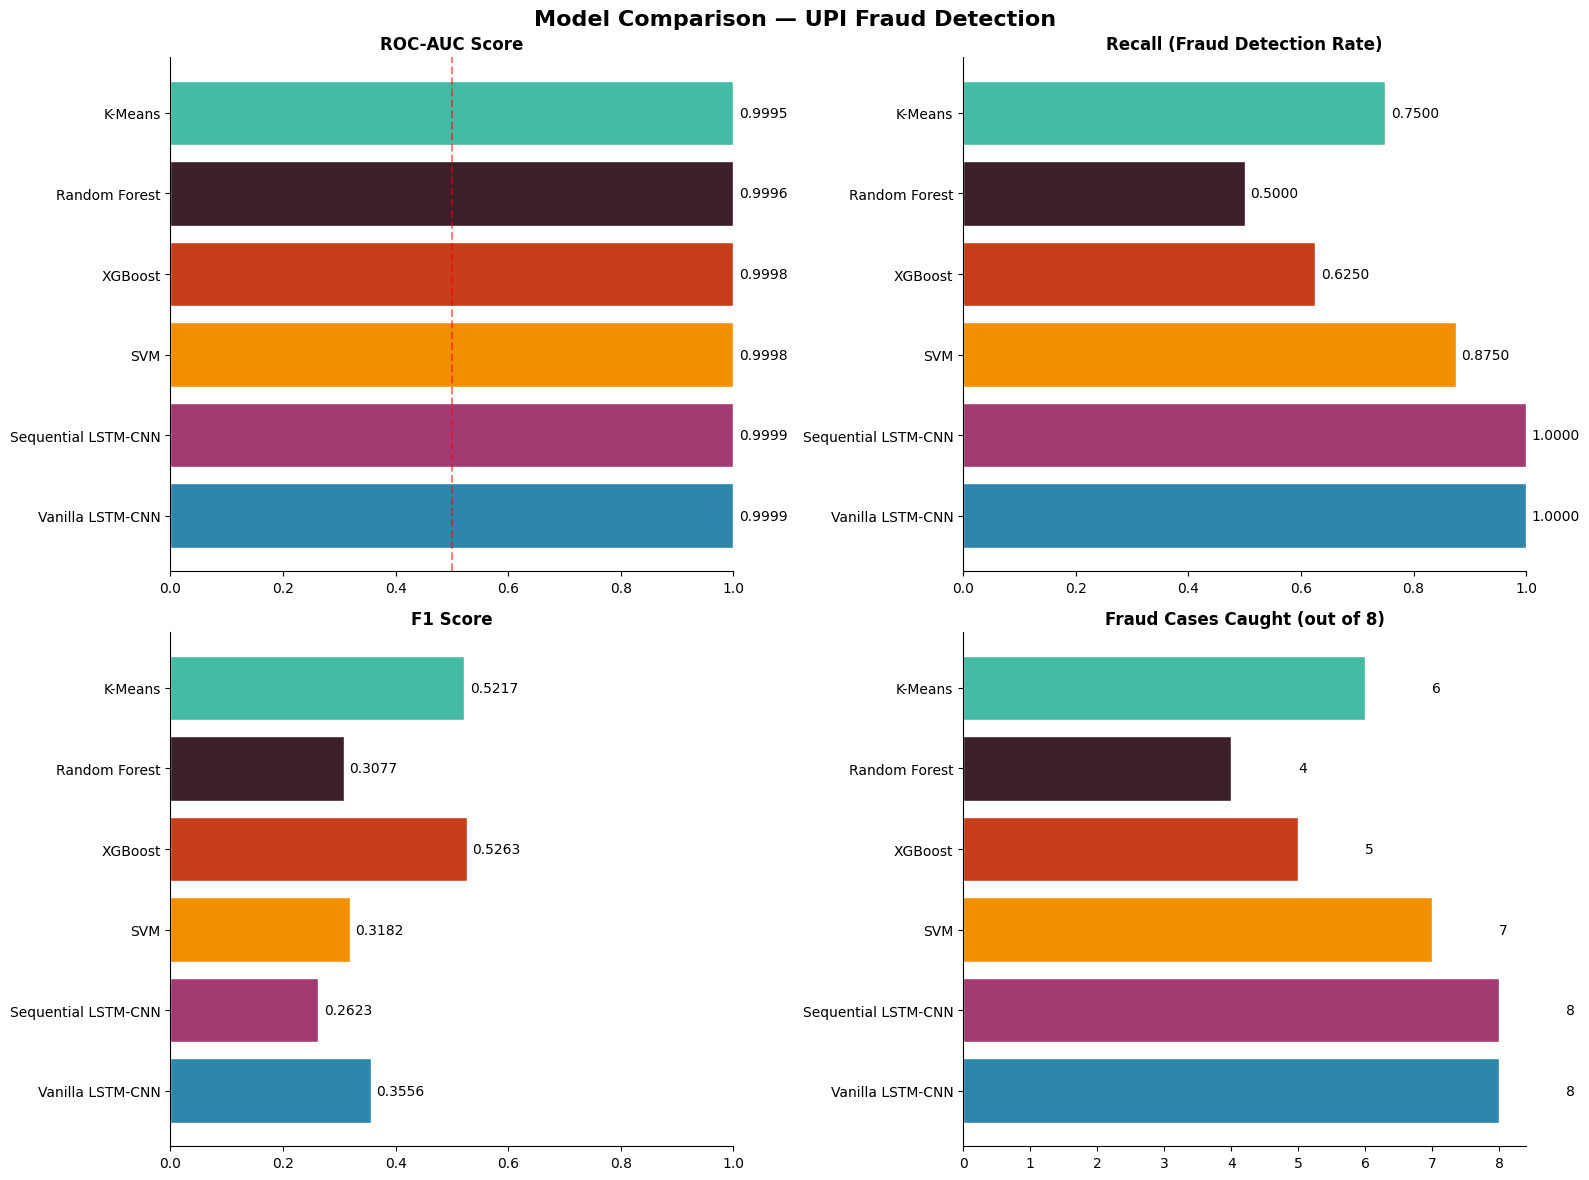

Comparison chart saved.


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Comparison — UPI Fraud Detection',
             fontsize=16, fontweight='bold')

models_list = comparison_df['model'].tolist()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']

# Chart 1 — ROC-AUC
axes[0,0].barh(models_list, comparison_df['roc_auc'],
               color=colors, edgecolor='white')
axes[0,0].set_title('ROC-AUC Score', fontweight='bold')
axes[0,0].set_xlim(0, 1)
axes[0,0].axvline(x=0.5, color='red', linestyle='--',
                  alpha=0.5, label='Random baseline')
for i, v in enumerate(comparison_df['roc_auc']):
    axes[0,0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Chart 2 — Recall (fraud caught rate)
axes[0,1].barh(models_list, comparison_df['recall'],
               color=colors, edgecolor='white')
axes[0,1].set_title('Recall (Fraud Detection Rate)', fontweight='bold')
axes[0,1].set_xlim(0, 1)
for i, v in enumerate(comparison_df['recall']):
    axes[0,1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Chart 3 — F1 Score
axes[1,0].barh(models_list, comparison_df['f1'],
               color=colors, edgecolor='white')
axes[1,0].set_title('F1 Score', fontweight='bold')
axes[1,0].set_xlim(0, 1)
for i, v in enumerate(comparison_df['f1']):
    axes[1,0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Chart 4 — Fraud caught count
axes[1,1].barh(models_list,
               comparison_df['fraud_caught'],
               color=colors, edgecolor='white')
axes[1,1].set_title(f'Fraud Cases Caught (out of {int(winner["total_fraud"])})',
                    fontweight='bold')
for i, v in enumerate(comparison_df['fraud_caught']):
    axes[1,1].text(v + 1, i, str(v), va='center', fontsize=10)

for ax in axes.flatten():
    ax.set_xlabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved.")

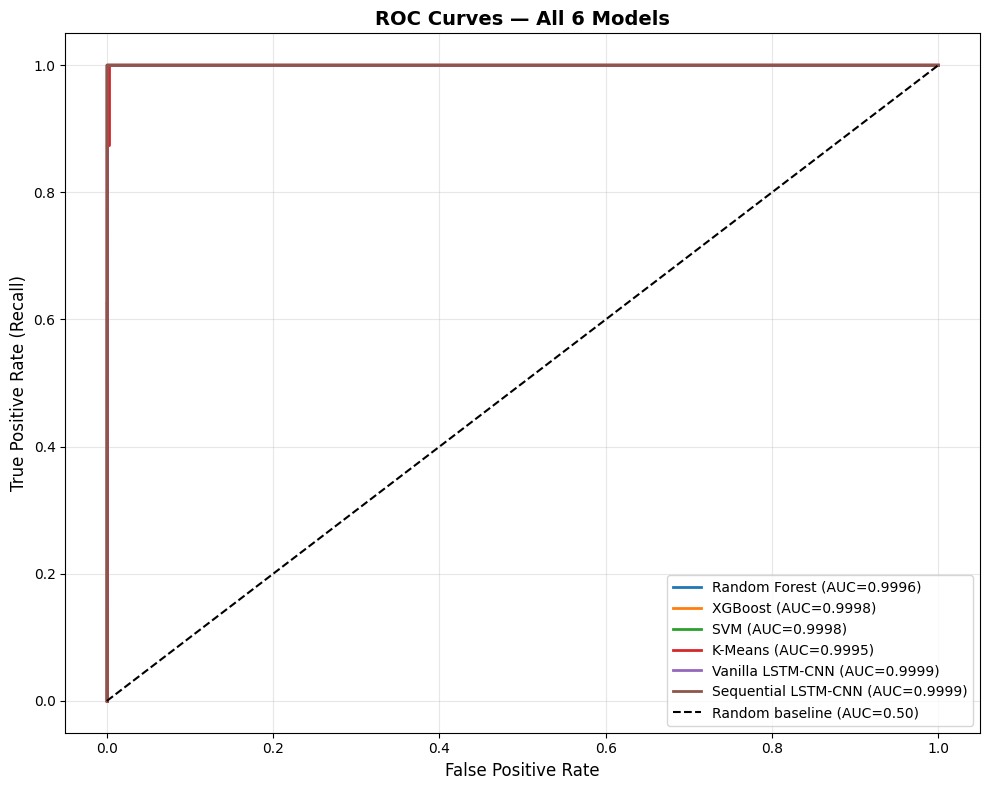

In [25]:
plt.figure(figsize=(10, 8))

all_probs = {
    'Random Forest':       rf_prob,
    'XGBoost':             xgb_prob,
    'SVM':                 svm_prob,
    'K-Means':             kmeans_prob,
    'Vanilla LSTM-CNN':    vanilla_prob,
    'Sequential LSTM-CNN': seq_prob
}

for name, prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', lw=1.5,
         label='Random baseline (AUC=0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — All 6 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Select best model based on ROC-AUC
best_name = comparison_df.iloc[0]['model']
print(f"Best model: {best_name}")

model_map = {
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'SVM':                 svm,
    'K-Means':             kmeans,
    'Vanilla LSTM-CNN':    vanilla_model,
    'Sequential LSTM-CNN': seq_model
}

threshold_map = {
    'Random Forest':       rf_thresh,
    'XGBoost':             xgb_thresh,
    'SVM':                 svm_thresh,
    'K-Means':             kmeans_thresh,
    'Vanilla LSTM-CNN':    vanilla_thresh,
    'Sequential LSTM-CNN': seq_thresh
}

best_model     = model_map[best_name]
best_threshold = threshold_map[best_name]

# Save best model
if 'LSTM' in best_name:
    best_model.save('../model/best_model.h5')
    joblib.dump({'type': 'keras', 'threshold': best_threshold,
                 'name': best_name}, '../model/best_model_meta.pkl')
else:
    joblib.dump(best_model, '../model/best_model.pkl')
    joblib.dump({'type': 'sklearn', 'threshold': best_threshold,
                 'name': best_name}, '../model/best_model_meta.pkl')

print(f"Best model saved with threshold: {best_threshold}")
print(f"This model will replace fraud_model.pkl in the API.")

Best model: Vanilla LSTM-CNN
Best model saved with threshold: 0.9000000000000001
This model will replace fraud_model.pkl in the API.


In [ ]:
# Cell 17 — Fix meta to include all fields dashboard needs
import joblib, os

meta = joblib.load('../model/best_model_meta.pkl')
winner_row = comparison_df[comparison_df['model'] == meta['name']].iloc[0]

# Add missing fields
meta['auc']     = float(winner_row['roc_auc'])
meta['recall']  = float(winner_row['recall'])
meta['f1']      = float(winner_row['f1'])
meta['score']   = float(winner_row['roc_auc'])  # use AUC as score
meta['is_seq']  = 'Sequential' in meta['name']

joblib.dump(meta, '../model/best_model_meta.pkl')
print("Updated meta:", meta)

Updated meta: {'type': 'keras', 'threshold': np.float64(0.9000000000000001), 'name': 'Sequential LSTM-CNN', 'auc': 0.9999, 'recall': 1.0, 'f1': 0.5926, 'score': 0.9999, 'is_seq': True}
